In [1]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import  Ball3StickSharedDiffusivity
from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx

import matplotlib.pyplot as plt

plt.style.use("../dmri/utils/pyloric_black.mplstyle")

# Ignore font warnings from matplotlib
import warnings
warnings.filterwarnings("ignore")
# Ignore missing font warnings from seaborn
warnings.filterwarnings("ignore", module="matplotlib.font_manager")


sim_type = Ball3StickSharedDiffusivity
ball_stick = sim_type.from_theta(np.random.randn(sim_type.theta_dim))

Duplicate key in file '../dmri/utils/pyloric_black.mplstyle', line 65 ('savefig.facecolor    : black       # Ensures black background when saving')


In [2]:
from dmri.simulators.acquisition_scheme import acquisition_scheme, random_hcp_acquisition



@jax.jit
def simulator(rng):
    rng0, rng1, rng2, rng3, rng4, rng5 = jax.random.split(rng, 6)
    rng0_1, rng0_2 = jax.random.split(rng0)
    acq = random_hcp_acquisition(rng0_2)
    theta = jax.random.normal(rng1, shape=(sim_type.theta_dim,))
    rng_p, rng_m = jax.random.split(rng2)
    p_mask = jax.random.beta(rng_p, a=1, b=1, shape=(1,))
    model_mask = jax.random.bernoulli(rng_m, p=p_mask, shape=(len(sim_type.model_types)))
    # This needs to have only one entry
    model_noise_idx = jax.random.randint(rng4, minval=0, maxval=len(sim_type.noise_types), shape=(1,))
    model_noise_mask = jnp.zeros(len(sim_type.noise_types), dtype=jnp.bool)
    model_noise_mask = model_noise_mask.at[model_noise_idx].set(True)
    model_mask = jnp.concatenate([model_mask, model_noise_mask], axis=-1)
    ball_stick = sim_type.from_theta(theta, model_mask=model_mask)

    x_o = ball_stick.signal(acq, rng=rng5)
    return p_mask, model_mask, theta, x_o, acq


In [3]:
p_mask,masks, theta, x_o, acq= jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=200))

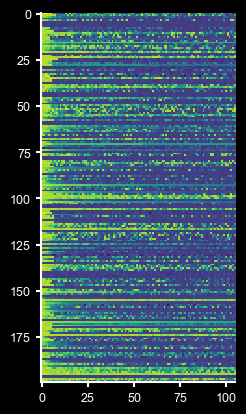

In [4]:
import matplotlib.pyplot as plt
plt.imshow(x_o)

In [5]:
from dmri.nn.dmri_reconstruction_model import DMRIInferenceModel, DMRIInferenceModelConfig, DMRIInferenceModelConfigMaskPriorAmortized, DMRIInferenceModelConfigMaskPriorAmortizedPP
from dmri.nn.tokenizer import DMRITokenizerPP

cfg = DMRIInferenceModelConfigMaskPriorAmortized(sim_type, use_attention_mask=True)
model = DMRIInferenceModel(cfg, nnx.Rngs(1))

In [6]:
import optax

scheduler = optax.cosine_onecycle_schedule(100*500, 5e-4)
optimizer = optax.chain(optax.adaptive_grad_clip(50.), optax.ema(0.01), optax.adamw(scheduler))

params = nnx.state(model, nnx.Param)
opt_state = optimizer.init(params)


In [7]:

def loss_fn(params, data, rng):
    nnx.update(model, params)
    p_mask, model_mask, thetas,  xs, bvals, bvecs = data
    return model.loss_fn(rng,model_mask=model_mask, theta=thetas, x=xs,bvals=bvals, bvecs=bvecs, mask_prior=p_mask).sum()


@jax.jit
def update(params, opt_state, data, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, data, rng)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [8]:
batch_simulator = jax.jit(jax.vmap(simulator))

In [9]:
key = jax.random.PRNGKey(42)
for i in range(150):
    key, subkey1 = jax.random.split(key, 2)
    p_mask, masks, thetas, x_os, acq = batch_simulator(jax.random.split(subkey1, 2**16))
    l = 0
    for j in range(50):
        key, subkey2 = jax.random.split(key, 2)
        idx = jax.random.randint(subkey2, (128,), 0, 2**16)
        p_mask_batch, masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch = p_mask[idx],masks[idx], thetas[idx], x_os[idx], acq.bvals[idx], acq.bvecs[idx]
        params, opt_state, loss = update(params, opt_state, (p_mask_batch,masks_batch, thetas_batch, x_os_batch, bvals_batch, bvecs_batch), subkey2)
        l += loss
    print(l/50)

(0, 1, 2, 3, 4)
7.285736
4.9880905
4.139741
3.8022118
3.6257582
3.535767
3.4764628
3.4423892
3.387375
3.4024332
3.4095135
3.3477468
3.3663304
3.3534079
3.360606
3.3289647
3.3271708
3.3136241
3.314533
3.3103247
3.3234618
3.3228633
3.3297482
3.299132
3.3109508
3.3289757
3.3083506
3.2936206
3.3050463
3.2945657
3.2894526
3.2902822
3.345592
3.3047988
3.3091347
3.315465
3.3040454
3.308505
3.2850585
3.318019
3.2867818
3.2908702
3.3043196
3.3065639
3.3264732
3.281638
3.279154
3.2934833
3.285698
3.2731051
3.3180318
3.3108773
3.2595868
3.2780228
3.249755
3.3058467
3.301536


KeyboardInterrupt: 

In [10]:
nnx.update(model, params)

In [11]:
batch_simulator = jax.jit(jax.vmap(simulator))
p_mask, masks, thetas, x_os, acq = batch_simulator(jax.random.split(jax.random.key(0), 100))

In [20]:
#idx = 2
idx = 15

In [21]:
mask = jax.vmap(model.sample_mask, in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 128), acq.bvals[idx], acq.bvecs[idx], x_os[idx], jnp.array([0.3]))

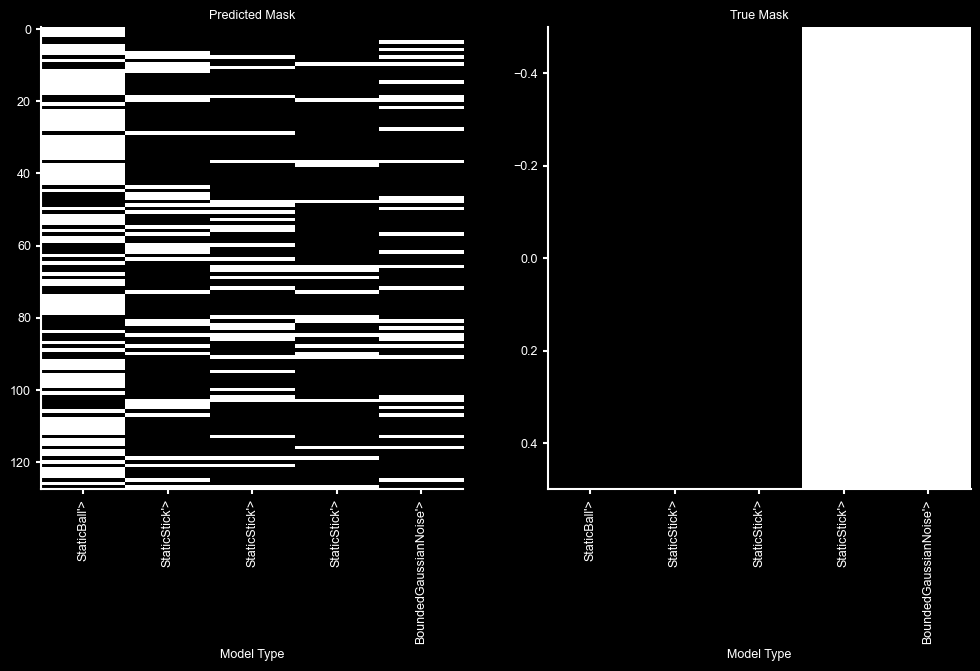

In [22]:
plt.figure(figsize=(12, 6))

# Plot predicted mask
plt.subplot(1, 2, 1)
plt.imshow(mask, aspect='auto', cmap='gray', vmin=0, vmax=1)
plt.title('Predicted Mask')
plt.xlabel('Model Type')
plt.xticks(range(len(sim_type.model_types) + len(sim_type.noise_types)), [str(m).split(".")[-1] for m in sim_type.model_types] + [str(m).split(".")[-1] for m in sim_type.noise_types], rotation=90)

# Plot true mask
mask_true = masks[idx]
plt.subplot(1, 2, 2)
plt.imshow(mask_true[None], aspect='auto', cmap='gray', vmin=0, vmax=1)
plt.title('True Mask')
plt.xlabel('Model Type')
plt.xticks(range(len(sim_type.model_types) + len(sim_type.noise_types)), [str(m).split(".")[-1] for m in sim_type.model_types] + [str(m).split(".")[-1] for m in sim_type.noise_types], rotation=90)

plt.show()

In [15]:
from functools import partial

In [16]:
thetas_post = jax.vmap(partial(model.sample_theta, num_steps=128, max_noise=20), in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 4096), acq.bvals[idx], acq.bvecs[idx], x_os[idx],masks[idx])

(0, 1, 2, 3, 4)


TypeError: Indexer must have integer or boolean type, got indexer with type float32 at position 0, indexer value []

In [ ]:
import sbi
from sbi.analysis.plot import pairplot

_ = pairplot(thetas_post, points=[thetas[idx],], limits=[[-3,3]*100], labels=[f'$\\theta_{i}$' for i in range(100)], figsize=(25, 25))

In [ ]:
def posterior_pred(theta,rng):
    return sim_type.from_theta(theta, model_mask=masks[idx]).signal(acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), rng=rng)

def loglikelihood(theta):
    simulator = sim_type.from_theta(theta, model_mask=masks[idx])
    ll = simulator.log_likelihood(acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), x_os[idx])
    return ll

posterior_preds = jax.vmap(posterior_pred)(thetas_post, jax.random.split(jax.random.key(0), 4096))